# Imports

In [1]:
# Imports used within this project
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from itertools import product
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from dieboldmariano import dm_test
from src import XGBoostTimeSeries

# Reload helper files in case
# changes are made
import importlib
importlib.reload(XGBoostTimeSeries)

<module 'src.XGBoostTimeSeries' from 'C:\\Users\\denve\\OneDrive - University of Southampton\\Python projects\\Timeseries\\src\\XGBoostTimeSeries.py'>

# The dataset and task

We take [this](https://www.kaggle.com/datasets/muhammadaammartufail/silver-prices-10-year-data-and-2026-forecast/) 10-year silver pricing data and investigate whether a classical model (ARIMA) and a machine learning model (XGBoost) can outperform a random walk baseline in forecasting **closing prices**. The data runs from 19/01/2016 to 15/01/2026.

The dataset has 7 columns: `Date`, `Price`, `Close`, `High`, `Low`, `Open`, `Volume`:

1. `Date`: the date of the pricing data.
2. `Price`: this column doesn't have a clear definition.
3. `Open`, `High`, `Low`, `Close`: in market data, these columns are abbreviated as OHLC. They usually correspond to: the opening price of the commodity, the highest price the commodity achieved on that date, the lowest price it achieved on that date, and the price the commodity finished with respectively.
4. `Volume`: usually a measure of how much of the commodity was traded during that window.

# Data validation and cleaning

We load in the data and inspect the first few columns:

In [2]:
# Read in the csv
df = pd.read_csv("data/silver_prices_data.csv")

# Let's observe the first 10 samples
print(df.head(10))

# ... and see how many samples we have
print("Number of samples: " + str(len(df)))

         Date   Price   Close    High     Low  Open  Volume
0  2016-01-19  14.110  14.110  14.065  14.065     3     NaN
1  2016-01-20  14.147  14.147  14.147  14.147     1     NaN
2  2016-01-21  14.083  14.083  14.083  14.083     2     NaN
3  2016-01-22  14.043  14.290  14.043  14.290     7     NaN
4  2016-01-25  14.240  14.240  14.095  14.095     8     NaN
5  2016-01-26  14.544  14.544  14.385  14.385     1     NaN
6  2016-01-27  14.440  14.440  14.440  14.440    53     NaN
7  2016-01-28  14.216  14.355  14.215  14.355    27     NaN
8  2016-01-29  14.229  14.265  14.229  14.229    27     NaN
9  2016-02-01  14.329  14.370  14.235  14.245     9     NaN
Number of samples: 2513


A few things stand out:

1. `Volume` doesn't take any value. We will call `df["Volume"].value_counts()` to validate whether or not this column is empty throughout the whole dataset.
2. For the first few entries, it seems `Price` is a duplicate of `Close`; however, in the fourth entry above, we see this isn't the case.
3. We see that for a couple of the above entries, `Low` is actually larger than `High`, which doesn't make sense.
4. `Open` is unusual: we would expect this to be a float with comparable value to the other columns.
5. The sample dates are roughly daily, but not quite. This is important to note because most forecasting models typically require regular sampling intervals.
6. We only have a couple of thousand samples. This makes more complex machine learning models, such as neural networks, less well justified.

In [3]:
# Let's see if the `Volume` column is empty everywhere
print(df["Volume"].value_counts())

Series([], Name: count, dtype: int64)


Since `Volume` is empty everywhere, we simply drop this column:

In [4]:
df = df.drop(["Volume"],axis=1)
print(df.head(10))

         Date   Price   Close    High     Low  Open
0  2016-01-19  14.110  14.110  14.065  14.065     3
1  2016-01-20  14.147  14.147  14.147  14.147     1
2  2016-01-21  14.083  14.083  14.083  14.083     2
3  2016-01-22  14.043  14.290  14.043  14.290     7
4  2016-01-25  14.240  14.240  14.095  14.095     8
5  2016-01-26  14.544  14.544  14.385  14.385     1
6  2016-01-27  14.440  14.440  14.440  14.440    53
7  2016-01-28  14.216  14.355  14.215  14.355    27
8  2016-01-29  14.229  14.265  14.229  14.229    27
9  2016-02-01  14.329  14.370  14.235  14.245     9


The dataset claims to come from *Yahoo Finance*. This luckily means that we can try to validate these other columns by comparing with the [source](https://uk.finance.yahoo.com/quote/SI%3DF/history/) of the data.

A manual direct comparison revealed that:

1. The `Price` column is actually the closing price in USD.
2. The `Close` column is actually the high price in USD.
3. The `High` column is actually the low price in USD.
4. The `Low` column is actually the opening price in USD.
5. The `Open` column is actually the volume.

Furthermore, manual inspection revealed that missing dates within the data corresponded with non-trading days (e.g. weekends). Thus for the purpose of modelling, if ${C_t}$ denotes the silver closing price at time $t$, then ${C_{t+1}}$ means "the silver closing price on the next trading day", which isn't necessarily the next literal date.

We now relabel the columns accordingly.

In [5]:
# Kaggle mislabeled OHLC columns; this block restores the correct mapping
df["Volume"] = df["Open"]
df["Open"] = df["Low"]
df["Low"] = df["High"]
df["High"] = df["Close"]
df["Close"] = df["Price"]
df = df.drop(["Price"],axis=1)

# While we are at it, let's also ensure the samples
# are ordered from lowest date to highest
df = df.sort_values(["Date"])

print(df.head(10))

         Date   Close    High     Low    Open  Volume
0  2016-01-19  14.110  14.110  14.065  14.065       3
1  2016-01-20  14.147  14.147  14.147  14.147       1
2  2016-01-21  14.083  14.083  14.083  14.083       2
3  2016-01-22  14.043  14.290  14.043  14.290       7
4  2016-01-25  14.240  14.240  14.095  14.095       8
5  2016-01-26  14.544  14.544  14.385  14.385       1
6  2016-01-27  14.440  14.440  14.440  14.440      53
7  2016-01-28  14.216  14.355  14.215  14.355      27
8  2016-01-29  14.229  14.265  14.229  14.229      27
9  2016-02-01  14.329  14.370  14.235  14.245       9


# Main methodology for comparison

We first produce a test-train split. Because the data is a time-series, we **cannot** randomly split the data, as this would introduce data leakage. Instead, we use the first ${\approx 80\%}$ of the data (2000 rows) for training, and reserve the last 513 rows for testing:

In [6]:
train_split = df.head(2000)
test_split = df.tail(len(df) - 2000)

To compare the performance of our model forecasts on the final test data, we could compare the RMSE scores achieved over the test split; however, how do we truly know if a small drop in RMSE in statistically meaningful? To provide a more principled comparison, we will use a *Dielbold-Mariano test*. Let ${\widehat{C}_{1,t}}$ and ${\widehat{C}_{2,t}}$ be the predictions for the silver closing price at time $t$ for two different models. Let
$$
\begin{aligned}
e_{1,t}&=C_{t} - \widehat{C}_{1,t}\\
e_{2,t}&=C_{t} - \widehat{C}_{2,t}
\end{aligned}
$$
denote the error in the forecasting prediction of the two models. Let ${L}$ be a loss function: in our case, we will use the square error: ${L(e_{i,t}) = e_{i,t}^2}$. Finally, let
$$
d_t := L(e_{1,t}) - L(e_{2,t})
$$
be the difference of the losses at time $t$. Then the Dielbold-Mariano test is a hypothesis test with the following null and alternative hypothesis:
$$
\begin{aligned}
H_0:&\mathbb{E}[d_t] = 0\\
H_1:&\mathbb{E}[d_t]\neq 0.
\end{aligned}
$$
In other words, ${H_0}$ states that the two models have the same expected forecasting losses, while ${H_1}$ states that their expected forecasting loss differs.

# The random walk baseline

For our baseline, we model the closing price as a *random walk*. This model takes the form:
$$
C_t = C_{t-1} + \epsilon_t
$$
where ${C_t}$ is the closing price at time $t$, and ${\epsilon_t}$ is a white noise term; that is:

1. ${\mathbb{E}[\epsilon_t] = 0\ \forall t}$.
2. ${\text{Var}(\epsilon_t) = \text{Var}(\epsilon_s)\ \forall\ t,s}$.
3. It has zero *autocorrelation*, which is equivalent to ${\text{Cov}(\epsilon_t,\epsilon_s) = 0\ \forall\ t,s}$.

Under this model, ${\mathbb{E}[C_t | C_{t-1}] = C_{t-1}}$, and the most optimal value to report for ${C_t}$ in minimising the RMSE is simply ${C_{t-1}}$. In other words, our prediction based on this model is simply:
$$
\widehat{C_{t}} = C_{t-1}.
$$
"Tomorrows closing price is todays closing price". We can easily fill in these predictions:

In [7]:
# Just shift the closing prices down by 1 to get
# the random walk prediction
df["model1_pred"] = df["Close"].shift(1)

# Record the predictions in the test set
test_split["model1_pred"] = df["model1_pred"].tail(len(df["model1_pred"]))

df = df.drop(["model1_pred"],axis=1)
print(test_split.head(10))

            Date      Close       High        Low       Open  Volume  \
2000  2024-01-03  22.945999  23.264999  22.930000  23.264999     458   
2001  2024-01-04  22.989000  23.045000  22.705000  22.930000      24   
2002  2024-01-05  23.122000  23.122000  22.865000  23.065001       5   
2003  2024-01-08  23.120001  23.120001  22.834999  22.990000      53   
2004  2024-01-09  22.903999  23.139999  22.903999  23.139999      19   
2005  2024-01-10  22.884001  23.000000  22.799999  23.000000      10   
2006  2024-01-11  22.537001  23.084999  22.535000  22.959999     109   
2007  2024-01-12  23.162001  23.379999  22.825001  22.825001      44   
2008  2024-01-16  22.933001  22.933001  22.933001  22.933001       0   
2009  2024-01-17  22.516001  22.910000  22.510000  22.910000      17   

      model1_pred  
2000    23.733000  
2001    22.945999  
2002    22.989000  
2003    23.122000  
2004    23.120001  
2005    22.903999  
2006    22.884001  
2007    22.537001  
2008    23.162001  
2009   

# ARIMA

We will now attempt to forecast the silver closing prices using an ARIMA model. ARIMA has three parameters:

1. ${d}$: the differencing parameter, which is what the I in ARIMA (standing for "Integrated") refers to. Given a time series ${X_t}$, we can define a new time series ${(\Delta X)_t := X_t - X_{t-1}}$. The parameter $d$ controls how many times we apply ${\Delta}$ to the original time series. Differencing is done in hope that we can achieve *stationarity*, which we explain in more detail shortly.
2. $p$: the autoregressive order. This controls how many past values are used in the next prediction. An AR(p) model takes the form
$$X_t = \phi + \phi_1X_{t-1} + \phi_2 X_{t-2} + ... + \phi_pX_{t-p} + \epsilon_t$$
where ${\phi,\phi_1,...,\phi_p}$ are coefficients of the model, and ${\epsilon_t}$ is a shock term (white noise).
3. $q$: the moving average order. This controls how many of the past shock terms have **direct** influence over the next term in the series. An MA(q) model takes the form
$$X_t = \epsilon_t + \theta_1 \epsilon_{t-1} + ... \theta_q \epsilon_{t-q}$$
where ${\epsilon_t}$ is white noise for each $t$.

Put together, an ARIMA(p,d,q) model for a time series ${X_t}$ does the following: we apply the difference operator $d$ times to the original time series to get a new series: ${Y_t := (\Delta^d X)_t}$, and fit:
$$
Y_t = \phi_0 + \sum_{i=1}^{p}\phi_i Y_{t-i} + \epsilon_t + \sum_{j=1}^{q}\theta_j \epsilon_{t-j}.
$$

One thing to note: an ARIMA(0,1,0) model is equivalent to a random walk.

## Box-Jekins methodology

In order to train an ARIMA model to our dataset, we must first choose suitable ${p,q,d}$ values. The Box-Jenkins method gives us a principled way of approaching this.

### Stationarity (determining $d$)

We first determine a suitable value for $d$ by assessing stationarity. A time series ${X_t}$ is called (weakly) *stationary* if its statistical properties stay the same over time:

1. ${\mathbb{E}[X_t] = \mu}$ is the same for all $t$.
2. ${\text{Var}(X_t) = \sigma^2}$ is the same for all $t$.
3. ${\text{Cov}(X_t,X_{t+k}) = \gamma(k)}$ depends only on the lag $k$, not the time $t$.

In other words, a stationary process has a stable underlying structure, meaning that patterns observed in the past remain representative of future behaviour. We choose $d$ such that ${(\Delta^d C)_t}$ exhibits evidence of stationarity.

It seems unlikely that the original closing price series ${C_t}$ would be stationary. One reason we may reasonably doubt this is inflation: inflation is one factor that can contribute to an upward trend in nominal prices over time. We will plot the time series ${C_t}$ along with a rolling average as a first step in validating whether the series seems stationary:

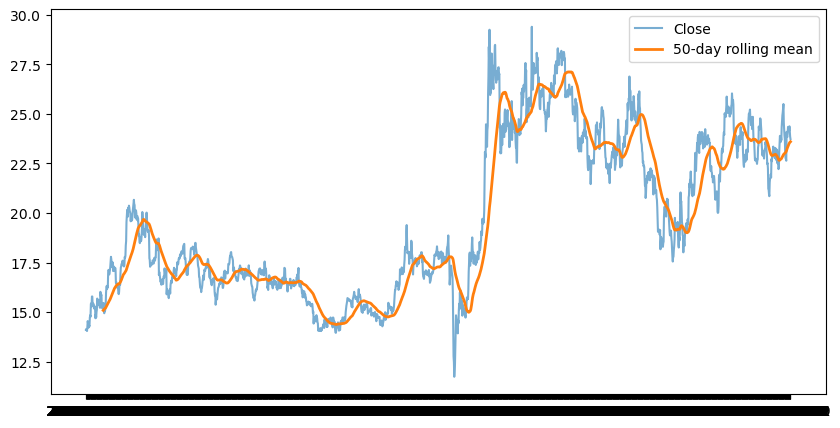

In [8]:
# Compute the rolling average, here with a window size of 25.
train_split["roll_mean_50"] = train_split["Close"].rolling(window=50).mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_split["Date"], train_split["Close"], label="Close", alpha=0.6)
plt.plot(train_split["Date"], train_split["roll_mean_50"], label="50-day rolling mean", linewidth=2)
plt.legend()
plt.show()

# Cleanup
train_split = train_split.drop(["roll_mean_50"],axis=1)

Visually, it seems unlikely to be stationary. We now move to taking the first difference, ${(\Delta C)_t = C_t - C_{t-1}}$, to see if this is plausibly stationary:

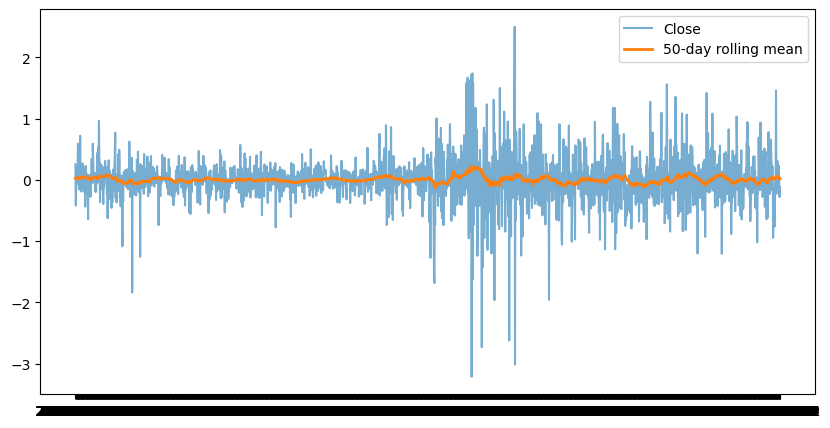

In [9]:
train_split["Close_diff"] = train_split["Close"].diff()
train_split["diff_roll_mean_50"] = train_split["Close_diff"].rolling(window=50).mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_split.dropna()["Date"], train_split.dropna()["Close_diff"], label="Close", alpha=0.6)
plt.plot(train_split.dropna()["Date"], train_split.dropna()["diff_roll_mean_50"], label="50-day rolling mean", linewidth=2)
plt.legend()
plt.show()

# Cleanup
train_split = train_split.drop(["diff_roll_mean_50", "Close_diff"],axis=1)

It seems much more plausible that this is stationary. As a final check, we'll perform an *Augmented Dickey-Fuller (ADF) test*. The most common way a time series can fail to be stationary is if it has a unit root. We won't go into the details of what that means precisely here, but the important thing for us is what the null and alternative hypotheses are in the ADF test. For a time series ${X_t}$,
$$
\begin{aligned}
H_0:&X_t\text{ has a unit root (and is thus non-stationary)}\\
H_1:&X_t\text{ doesn't have a unit root}.
\end{aligned}
$$
Let's go ahead and run the test on ${(\Delta C)_t}$:

In [10]:
result = adfuller(train_split["Close"].diff().dropna())
p_value = result[1]
print("P-value of the ADF test on (\Delta C)_t: " + str(p_value))

P-value of the ADF test on (\Delta C)_t: 9.453761193510083e-21


A $p$-value of ${\approx 9.5\times 10^{-21}}$ is far below any reasonable choice of significance level (e.g. ${5\%, 3\%, 1\%}$). Thus, we reject the null hypothesis that ${(\Delta C)_t}$ has a unit root. This provides strong evidence in favour of the alternative hypothesis that ${(\Delta C)_t}$ does not have a unit root, suggesting that the differenced series is stationary.

### Candidate $q$ values

To try and find suitable ${q}$ values to examine, we will use the *AutoCorrelation Function* (ACF). For a weakly stationary time series ${X_t}$, the ACF function is defined as
$$
\rho(h) := \frac{\text{Cov}(X_t,X_{t-h})}{\text{Var}(X_t)} = \text{Corr}(X_t,X_{t-h}).
$$
In other words, it is the Pearson correlation coefficient of ${X_t}$ with the lagged RV, ${X_{t-h}}$. A priori, this depends on $t$; however, by (weak) stationarity, it is independent on the choice of $t$.

For an MA(q) process, the ACF function satisfies ${\rho(h) = 0\ \forall\  h > q}$, and can thus be used to identify $q$. Of course, ARIMA(p,d,q) models also contain an autoregressive component, and this will mean that in general, the ACF doesn't necessarily completely vanish after $q$. Nevertheless, it can provide a sensible neighbourhood of guesses for $q$.

Let's plot the ACF function for ${(\Delta C)_t}$.

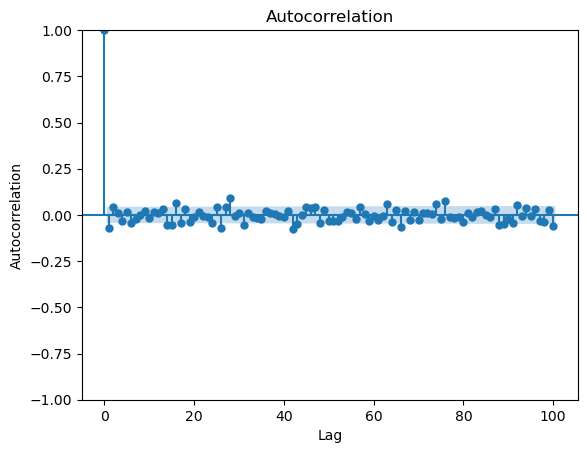

In [11]:
# We will plot it for up to lag == 50
fig = plot_acf(train_split["Close"].diff().dropna(), lags=100)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

We can see that for our differenced closing price series ${(\Delta C)_t}$, the ACF function dies very quickly: ${|\rho(h)| \approx 0\ \forall\ h\geq 1}$. This suggests that, when fitting an ARIMA(p,d,q) model, choosing $q$ to be small (say, ${q \in \{0,1,2\}}$) is most reasonable.

### Candidate $p$ values

Analogously to the ACF, we have the *Partial AutoCorrelation Function*, PACF, which we'll denote by ${\phi(h)}$. Let ${\phi_{1,h},\phi_{2,h}, ..., \phi_{h,h} \in \mathbb{R}}$ be such that
$$
\mathbb{E}\left[\left(X_t - \sum_{i=1}^{h}\phi_{i,h}X_{t-i}\right)^2\right]
$$
is minimised. Then ${\phi(h) := \phi_{h,h}}$. Intuitively, we are asking: "after accounting for any linear dependence of ${X_t}$ on ${X_{t-1},...,X_{t-h+1}}$, does ${X_t}$ still exhibit any linear dependence on ${X_{t-h}}$?"

When it comes to estimating $p$, the PACF plays a similar role as the ACF does for $q$: for a stationary AR(p) model, the PACF satisfies ${\phi(h) = 0\  \forall\ h > p}$. For an ARIMA(p,d,q) model, it can help us determine a sensible neighbourhood of $p$ values we can test.

We now plot the PACF for ${\Delta C_t}$:

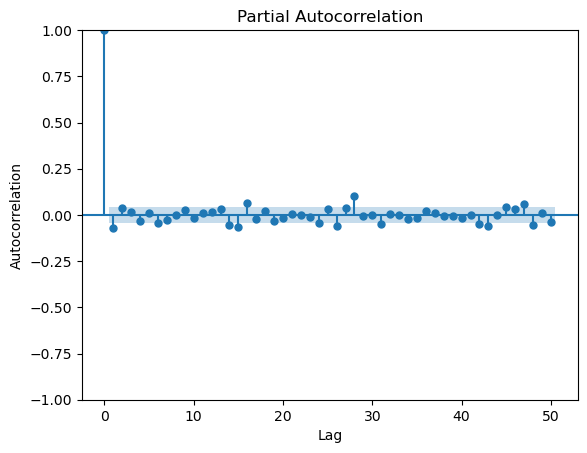

In [12]:
fig = plot_pacf(train_split["Close"].diff().dropna(), lags=50)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

Similarly to the ACF, the PACF for ${\Delta C_t}$ satisfies ${|\phi(h)| \approx 0}$ for ${h \geq 1}$. This suggests that, when fitting an ARIMA(p,d,q) model, choosing $p$ to be small (say ${p \in \{0,1,2\}}$) is most reasonable.

It should be noted that, when interpreted jointly, the above ACF and PACF plots are broadly consistent with those expected from a white noise process.

### Fitting the models

We will now fit some candidate ARIMA(p,d,q) models. We will specifically fit ARIMA(p,1,q) models with ${p,q \in \{0,1,2\} \times \{0,1,2\}}$. Furthermore, in order to decide which ARIMA model to bring foward for out-of-sample forecasting, we will use the *AIC* metric. AIC stands for *Akaike Information Criterion*, and is defined as
$$
\text{AIC} = 2k - 2\log(\widehat{L}),
$$
where $k$ is the number of parameters of the model, and ${\widehat{L}}$ is the maximised likelihood. Intuitively, the AIC measures the trade-off between model complexity and goodness of fit. While models with more parameters often fit the data better, the AIC penalises unnecessary complexity, favouring models that achieve a good fit using fewer parameters. Lower AIC values indicate a better balance between fit and complexity.

In [13]:
models = {}
fits = {}
aic = {}

# Range over, train, and keep track of AIC.
for p in range(0,3):
    for q in range(0,3):
        model = ARIMA(train_split["Close"], order=(p, 1, q))
        model_fit = model.fit()
        models[p,q] = model
        fits[p,q] = model_fit
        aic[p,q] = float(model_fit.aic)

for i, (k, v) in enumerate(aic.items()):
    print("ARIMA(" + str(k[0]) + ",1," + str(k[1]) + ") AIC: " + str(v))

ARIMA(0,1,0) AIC: 1853.1533163469992
ARIMA(0,1,1) AIC: 1845.6695439511013
ARIMA(0,1,2) AIC: 1843.6692023122487
ARIMA(1,1,0) AIC: 1844.9016293951083
ARIMA(1,1,1) AIC: 1845.3302146649305
ARIMA(1,1,2) AIC: 1845.6554307444792
ARIMA(2,1,0) AIC: 1844.1065222346024
ARIMA(2,1,1) AIC: 1845.9542165999717
ARIMA(2,1,2) AIC: 1844.3461374323088


As we can see, the random walk benchmark, ARIMA(0,1,0), has the highest AIC among the candidate models considered. The lowest AIC is achieved by ARIMA(0,1,2), which contains no autoregressive component but includes two moving-average terms. We therefore select ARIMA(0,1,2) as the candidate ARIMA model for out-of-sample forecasting.

It is worth noting that we could further investigate whether the residuals $\epsilon_t$ from the ARIMA(0,1,2) fit are consistent with white noise. Such diagnostics help assess whether the model has successfully captured the remaining autocorrelation structure in the data. However, since our primary objective is to evaluate whether ARIMA provides superior forecasting performance relative to the random walk baseline, we focus here on the out-of-sample forecast comparison.

We'll now record the ARIMA(0,1,2) predictions:

In [14]:
arima_fit = fits[0,2]
predictions = []
# Write down the first forecast
predictions.append(arima_fit.forecast(steps=1).iloc[0])

# Now enumerate through the test set.
for i in range(1,len(test_split)):
    # Update the model with the observed value.
    # We deliberately do not refit the model after
    # each update. Keeping the estimated parameters
    # fixed makes the comparison fairer, since the
    # random walk baseline does not have the ability
    # to re-estimate parameters at each step.
    arima_fit = arima_fit.append([test_split.head(i).tail(1)["Close"].item()], refit=False)
    # Now forecast again
    predictions.append(arima_fit.forecast(steps=1).iloc[0])

# Add the random walk baseline predictions alongside
test_split["modelarima_pred"] = predictions

print(test_split.head(10))

            Date      Close       High        Low       Open  Volume  \
2000  2024-01-03  22.945999  23.264999  22.930000  23.264999     458   
2001  2024-01-04  22.989000  23.045000  22.705000  22.930000      24   
2002  2024-01-05  23.122000  23.122000  22.865000  23.065001       5   
2003  2024-01-08  23.120001  23.120001  22.834999  22.990000      53   
2004  2024-01-09  22.903999  23.139999  22.903999  23.139999      19   
2005  2024-01-10  22.884001  23.000000  22.799999  23.000000      10   
2006  2024-01-11  22.537001  23.084999  22.535000  22.959999     109   
2007  2024-01-12  23.162001  23.379999  22.825001  22.825001      44   
2008  2024-01-16  22.933001  22.933001  22.933001  22.933001       0   
2009  2024-01-17  22.516001  22.910000  22.510000  22.910000      17   

      model1_pred  modelarima_pred  
2000    23.733000        23.727985  
2001    22.945999        22.994216  
2002    22.989000        22.953334  
2003    23.122000        23.110056  
2004    23.120001     

# XGBoost

We now move on to using XGBoost for our time series forecast. XGBoost itself is not strictly a time series model, but is instead a general purpose supervised machine learning model. We will need to engineer features from the dataset that take into account the temporal structure of the data for our forecasting purposes.

## Engineered features

We describe here our choice of engineered features.

1. `["Close_returns"]`: Rather than training the model to use the absolute price values (i.e. the data contained in column `["Close"]`), we use the returns ${r_t}$ at time $t$. This is defined as
$$ r_t = \frac{C_t - C_{t-1}}{C_{t-1}}. $$
The reason we choose to use returns instead of the original closing price value directly is because of how XGBoost works: it is a decision tree ensemble. It learns rules based on recursive splits in the data. If we use the closing price as a feature, it could learn rules that depend on the time period the sample was taken from. For instance, if it makes a split based on the silver closing price being ${\$14}$, but later, the prices increase in value (which they do) - the learned rule is unlikely to generalise well for out-of-sample forecasting. The hope is that, because returns account for the prevailing price level, the predictive rules learned by XGBoost will be less dependent on absolute price levels and therefore generalise better out of sample.
2. `["LowHigh_rel"]`: If ${L_t}$ and ${H_t}$ denote the low and high price of silver at time $t$, then our feature `[LowHigh_rel]` is defined as
$$\text{LowHigh\_rel}_t = \frac{H_t-L_t}{L_t}.$$
In other words, we are measuring "how much higher was the highest price than the lowest price at time $t$?". This gives a kind of intraday volatility measure: when predicting ${r_{t+1}}$, the model has access to how volatile the market was the previous trading day. This allows XGBoost to learn whether periods of higher or lower market volatility contain information that is useful for forecasting future returns.
3. `["Close_returns_roll10mean"]`: As the name suggests, we take the 10-day rolling average of ${r_t}$. The idea is that we are providing the model context about the history of ${r_t}$.
4. `["Close_returns_roll10std"]`: As the name suggests, we take the 10-day rolling standard deviation of ${r_t}$. We are providing the model context about the volatility in the last 10 days of the return prices.
5. `["Volume_rel"]`: If ${V_t}$ denotes the volume at time $t$, then this feature is defined as
$$\text{Volume\_rel}_t = \frac{V_t}{\text{10-day rolling average of }V_t.}$$
I wanted to include a measure of trade volume, but using the raw volume numbers could run into the same subtle issue as the closing prices. It doesn't take into account the historical context it occurred in: if there are more overall traders in 2024 than in 2016, for example, then comparing the raw number alone could be misleading.
6. `["Target"]`: This is simply ${r_{t+1}}$, the returns of the next trading day, which is the variable we are trying to predict.

After obtaining the prediction ${\widehat{r}_{t+1}}$ of the next trading day returns, we forecast our prediction of the closing price as ${\widehat{C}_{t+1} = C_t + \widehat{r}_{t+1} C_t}$.

## Class design and validation

I have engineered a custom class `XGBoostTimeSeries` to provide a nice time-series style interface over XGBoost:

1. The constructor takes a single argument, `train_split`, containing the training samples.
2. The method `fill_table()` takes the given training data, and computes the above engineered features, along with the target variable, ready for training.
3. The method `tune(initial_size, validation_sets, hyperparams)` is used to internally tune hyperparameters before fitting the final model. The class utilises walk-forward validation to test hyperparameter performance on the user-specified number of validation sets (`validation_sets`).
4. The method `fit()` fits the final model to the full training data, using the hyperparameters with the best average RMSE score across the validation sets. For `n_estimators` (the number of boosted iterations we perform for the final model), we use the median of the `best_iteration` values over each validation set.
5. The method `forecast()` returns the predicted silver closing price for the next time step (using ${\widehat{C}_{t+1} = C_t + \widehat{r}_{t+1} C_t}$).
6. The method `update(new_sample)` internally updates the last observation, ready for the model to make a prediction for the next time step.

When it comes to testing hyperparameters, we start with a small coarse grid search, and then refine the grid based on which combination gave the best average RMSE across validation sets. This process is repeated for only a small number of iterations to balance computational cost while reducing the risk of overfitting the hyperparameters to the validation data.

In [15]:
# Reload in case I made any changes
importlib.reload(XGBoostTimeSeries)

# The new xgboost object
modelx = XGBoostTimeSeries.XGBoostTimeSeries(train_split)
# Fills in the internal training table
modelx.fill_table()

# Refine the search around the current best-performing
# hyperparameter values from the previous iteration.
learning_rates = [0.025,0.030,0.035]
depths = [9,10,11]
lambdas = [1,5,10]
minchildweights = [9,10,11]
# Build the hyperparameter list
hyperparams = [
    {
        "learning_rate" : lr,
        "max_depth": d,
        "reg_lambda": l,
        "min_child_weight" : mcw
    }
    for lr,d,l,mcw in product(learning_rates,depths,lambdas,minchildweights)
]

# Do a small grid search with walk forward validation
# to tune hyperparameters
hp,best_iteration = modelx.tune(
    initial_size=1000, # Start with a training size of 1000,
    validation_sets=5, # and we'll use 5 validation sets.
    hyperparams=hyperparams
)

print("Current winning hyperparameters: " + str(hp.items()))
print("Current median best_iteration: " + str(best_iteration))

Current winning hyperparameters: dict_items([('learning_rate', 0.03), ('max_depth', 10), ('min_child_weight', 10), ('reg_lambda', 5)])
Current median best_iteration: 22


Now that we have a decently tuned XGBoost model, we'll perform the final fit to the full training data:

In [16]:
modelx.fit()

... and record the predictions it makes:

In [17]:
predictions = []
predictions.append(modelx.forecast())
new_samples = test_split[["Close", "High", "Low", "Volume"]]
for i in range(1,len(new_samples)):
    new_sample = new_samples.head(i).tail(1)
    modelx.update(new_sample)
    predictions.append(modelx.forecast())

test_split["modelx_pred"] = predictions

print(test_split.head(10))

            Date      Close       High        Low       Open  Volume  \
2000  2024-01-03  22.945999  23.264999  22.930000  23.264999     458   
2001  2024-01-04  22.989000  23.045000  22.705000  22.930000      24   
2002  2024-01-05  23.122000  23.122000  22.865000  23.065001       5   
2003  2024-01-08  23.120001  23.120001  22.834999  22.990000      53   
2004  2024-01-09  22.903999  23.139999  22.903999  23.139999      19   
2005  2024-01-10  22.884001  23.000000  22.799999  23.000000      10   
2006  2024-01-11  22.537001  23.084999  22.535000  22.959999     109   
2007  2024-01-12  23.162001  23.379999  22.825001  22.825001      44   
2008  2024-01-16  22.933001  22.933001  22.933001  22.933001       0   
2009  2024-01-17  22.516001  22.910000  22.510000  22.910000      17   

      model1_pred  modelarima_pred  modelx_pred  
2000    23.733000        23.727985    23.717461  
2001    22.945999        22.994216    22.973686  
2002    22.989000        22.953334    23.004486  
2003   

# Model comparison

We now finish off by comparing the different model performances in out-of-sample forecasting. Let's first compare the RMSE scores:

In [18]:
# Get the errors for each model
test_split["model1_err"] = test_split["Close"] - test_split["model1_pred"]
test_split["modelarima_err"] = test_split["Close"] - test_split["modelarima_pred"]
test_split["modelx_err"] = test_split["Close"] - test_split["modelx_pred"]

# Compute the RMSE
rmse_model1 = np.sqrt(np.mean(test_split["model1_err"]**2))
rmse_modelarima = np.sqrt(np.mean(test_split["modelarima_err"]**2))
rmse_modelx = np.sqrt(np.mean(test_split["modelx_err"]**2))

print("Random walk baseline RMSE: " + str(rmse_model1))
print("ARIMA RMSE: " + str(rmse_modelarima))
print("XGBoost RMSE: " + str(rmse_modelx))

Random walk baseline RMSE: 1.1139658871973777
ARIMA RMSE: 1.0996164145714278
XGBoost RMSE: 1.1027529312879705


ARIMA(0,1,2) achieved the lowest RMSE of ${\approx 1.0996}$, with XGBoost being the runner-up, and the random walk baseline getting the highest RMSE. However, each of these scores are very close. Let's run the Diebold-Mariano tests, first comparing the random walk baseline to the XGBoost model:

In [19]:
actual = test_split["Close"].values
predx = test_split["modelx_pred"].values
pred1 = test_split["model1_pred"].values

_, p_value = dm_test(
    actual,
    predx,
    pred1,
    loss=lambda y, yhat: (y - yhat)**2
)

print("P-value of the DM test, between the XGBoost model and the random walk: " + str(p_value))

P-value of the DM test, between the XGBoost model and the random walk: 0.14098930441735602


A $p$-value of ${\approx 14.1\%}$ is above most reasonable choices of signifigance level (e.g. ${5\%, 3\%, 1\%}$). Therefore, we fail to reject the null hypothesis that the expected loss difference between the XGBoost and random walk forecasts is $0$. In other words, under the DM test, we fail to find statistically signifigant evidence of a model performance difference.

We now run the DM test between the ARIMA(0,1,2) and random walk model:

In [20]:
predarima = test_split["modelarima_pred"].values

_, p_value = dm_test(
    actual,
    predarima,
    pred1,
    loss=lambda y, yhat: (y - yhat)**2
)

print("P-value of the DM test, between the ARIMA(0,1,2) model and the random walk: " + str(p_value))

P-value of the DM test, between the ARIMA(0,1,2) model and the random walk: 0.34640842460082844


A $p$-value of ${\approx 34.6\%}$ is even higher, and above most reasonable choices of signifigance level. Therefore, we fail to reject the null hypothesis that the expected loss difference between the ARIMA(0,1,2) and random walk forecasts is $0$. Once again, under the DM test, we fail to find statistically signifigant evidence of a model performance difference.

Finally, let's run a DM test between the XGBoost and ARIMA(0,1,2) models:

In [21]:
_, p_value = dm_test(
    actual,
    predx,
    predarima,
    loss=lambda y, yhat: (y - yhat)**2
)

print("P-value of the DM test, between the ARIMA(0,1,2) model and the random walk: " + str(p_value))

P-value of the DM test, between the ARIMA(0,1,2) model and the random walk: 0.8093226991400193


We obtain a similar conclusion: a $p$-value of ${\approx 81\%}$ suggests the result is well within what is expected under the null hypothesis.

# Conclusion

We analysed silver OHLC pricing data and compared three modelling assumptions for forecasting closing prices. As a baseline, we used the random walk model, which predicts that tomorrow’s closing price will equal today’s. We then applied a Box-Jenkins methodology to fit an ARIMA model, selecting ARIMA(0,1,2) for out‑of‑sample evaluation. Finally, we trained an XGBoost model using engineered features that incorporated additional information such as volatility measures, in contrast to the univariate structure of the random walk and ARIMA models.

Using the Diebold–Mariano test to compare forecast accuracy, we found that neither the ARIMA(0,1,2) model nor the XGBoost model delivered statistically significant improvements over the random walk baseline. This suggests that, within the scope of our data and modelling choices, silver closing prices remain difficult to outperform using standard time‑series or machine‑learning approaches.